In [29]:
from common.paths import *
from avito.embeddings import *
from avito.features import extract_should_split_features

import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

Что внутри:

3000 объявлений
11 микрокатегорий из исходного справочника
кейсы разных типов:
single_direct
turnkey_no_split
turnkey_split
multi_service_split
multi_service_no_split
bullets_mixed
noisy_short
Колонки:


itemId: идентификатор объявления

sourceMcId: исходная микрокатегория объявления

sourceMcTitle: название исходной микрокатегории

description: текст объявления

targetDetectedMcIds: список всех найденных mcId в тексте

targetSplitMcIds: список mcId, по которым стоит создать дополнительные draft

shouldSplit: есть ли хотя бы один дополнительный draft

caseType: тип сценария

split: train / val / test


Статистика:

всего записей: 3000

доля shouldSplit=true: 0.371

train/val/test: {'train': 2094, 'test': 459, 'val': 447}

распределение кейсов: {'single_direct': 843, 'turnkey_no_split': 544, 'turnkey_split': 535, 'bullets_mixed': 307, 'multi_service_no_split': 294, 'multi_service_split': 252, 'noisy_short': 225}

In [34]:
data_fpath = get_avito_data_dpath() / "rnc_dataset_markup.json"
df = pd.read_json(data_fpath)

id_title_fpath = get_avito_data_dpath() / "rnc_mic_key_phrases.csv"
id_title_df = pd.read_csv(id_title_fpath)
df.head()

,itemId,sourceMcId,sourceMcTitle,description,targetDetectedMcIds,targetSplitMcIds,shouldSplit,caseType,split
0,1000001,101,Ремонт квартир и домов под ключ,"Всё виды строительных работ\r\nКачественно, в ...",[],[],False,no_other_microcategories_detected,NaN
1,1000002,101,Ремонт квартир и домов под ключ,Профессионально и качественно сделаем ремонт к...,"[102, 103, 105, 108, 109, 110]",[],False,other_microcategories_detected_but_not_split,NaN
2,1000003,101,Ремонт квартир и домов под ключ,"ремонт квартир, ванной комнате , балкон",[102],[],False,other_microcategories_detected_but_not_split,NaN
3,1000004,101,Ремонт квартир и домов под ключ,ЗBОНИТЕ KОHСУЛЬТАЦИЯ БЕCПЛАTНAЯ ПO ТУЛЬСKOЙ ОБ...,"[102, 103, 104, 105, 106, 107, 108, 109, 110]","[102, 103, 104, 105, 106, 107, 108, 109, 110]",True,split,NaN
4,1000005,101,Ремонт квартир и домов под ключ,Ремонт квартир любой сложности. Квартиры под к...,[],[],False,no_other_microcategories_detected,NaN


In [35]:
import ast

df["targetDetectedMcIds"] = df["targetDetectedMcIds"].apply(ast.literal_eval)

extended_detected_ids = [item for sublist in df["targetDetectedMcIds"] for item in sublist]
extended_detected_cats = [id_title_df.loc[id_title_df["mcId"] == int(mc_id), "mcTitle"].values[0] for mc_id in extended_detected_ids]
id_title = dict(zip(id_title_df["mcId"], id_title_df["mcTitle"]))
id_title

{101: 'Ремонт квартир и домов под ключ',
 102: 'Сантехника',
 103: 'Электрика',
 104: 'Натяжные потолки',
 105: 'Укладка плитки',
 106: 'Поклейка обоев',
 107: 'Малярные работы',
 108: 'Штукатурные работы',
 109: 'Напольные покрытия',
 110: 'Гипсокартон',
 111: 'Демонтажные работы'}

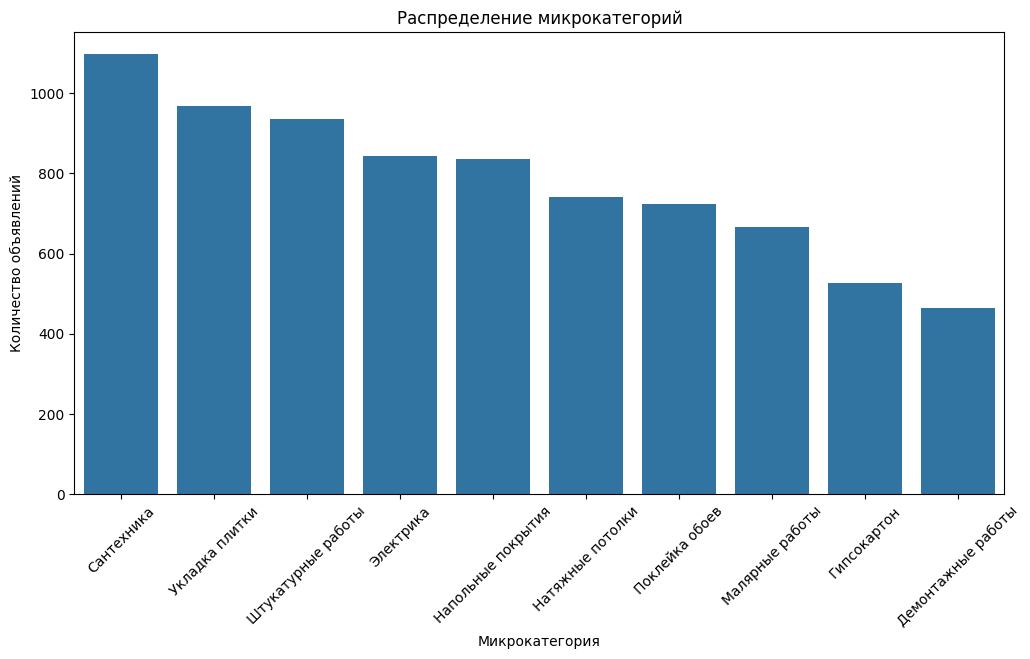

In [39]:
import ast

try:
    df["targetDetectedMcIds"] = df["targetDetectedMcIds"].apply(ast.literal_eval)

    extended_detected_ids = [item for sublist in df["targetDetectedMcIds"] for item in sublist]
except:
    pass
vc = pd.Series(extended_detected_ids).value_counts()

mc_title_dist = vc
mc_title_dist = vc.rename(index=lambda mc_id: id_title.get(int(mc_id), f"mcId_{mc_id}"))

plt.figure(figsize=(12, 6))
sns.barplot(x=mc_title_dist.index, y=mc_title_dist.values)
plt.xticks(rotation=45)
plt.title("Распределение микрокатегорий")
plt.xlabel("Микрокатегория")
plt.ylabel("Количество объявлений")
plt.show()

Топ-10 пар микрокатегорий, которые часто обнаруживаются вместе:
Сантехника & Укладка плитки: 743 раз
Сантехника & Электрика: 725 раз
Укладка плитки & Штукатурные работы: 663 раз
Штукатурные работы & Напольные покрытия: 645 раз
Сантехника & Штукатурные работы: 624 раз
Укладка плитки & Напольные покрытия: 615 раз
Поклейка обоев & Штукатурные работы: 609 раз
Сантехника & Напольные покрытия: 577 раз
Электрика & Укладка плитки: 562 раз
Малярные работы & Штукатурные работы: 562 раз


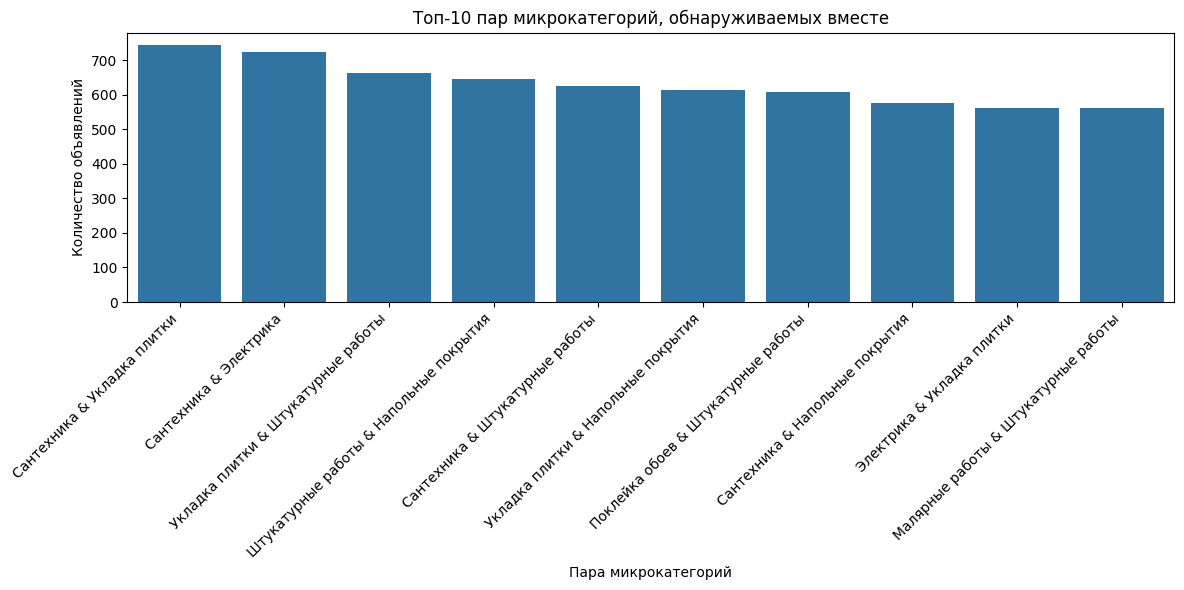

In [43]:
df["targetDetectedMcTitles"] = df["targetDetectedMcIds"].apply(lambda ids: [id_title.get(int(mc_id), f"mcId_{mc_id}") for mc_id in ids])
df["targetDetectedMcIds"] = df["targetDetectedMcIds"].apply(lambda ids: [int(mc_id) for mc_id in ids])

# correlation if microcategories detected together with each other
from itertools import combinations
from collections import Counter

co_occurrence = Counter()
for detected_ids in df["targetDetectedMcIds"]:
    for id1, id2 in combinations(set(detected_ids), 2):
        pair = tuple(sorted((id1, id2)))
        co_occurrence[pair] += 1
sorted_items = co_occurrence.most_common()
print("Топ-10 пар микрокатегорий, которые часто обнаруживаются вместе:")
for (id1, id2), count in sorted_items[:10]:
    title1 = id_title.get(id1, f"mcId_{id1}")
    title2 = id_title.get(id2, f"mcId_{id2}")
    print(f"{title1} & {title2}: {count} раз")

# plot
top_pairs = sorted_items[:10]
pair_labels = [f"{id_title.get(id1, f'mcId_{id1}')} & {id_title.get(id2, f'mcId_{id2}')}" for (id1, id2), _ in top_pairs]
pair_counts = [count for _, count in top_pairs]
plt.figure(figsize=(12, 6))
sns.barplot(x=pair_labels, y=pair_counts)
plt.xticks(rotation=45, ha="right")
plt.title("Топ-10 пар микрокатегорий, обнаруживаемых вместе")
plt.xlabel("Пара микрокатегорий")
plt.ylabel("Количество объявлений")
plt.tight_layout()
plt.show()

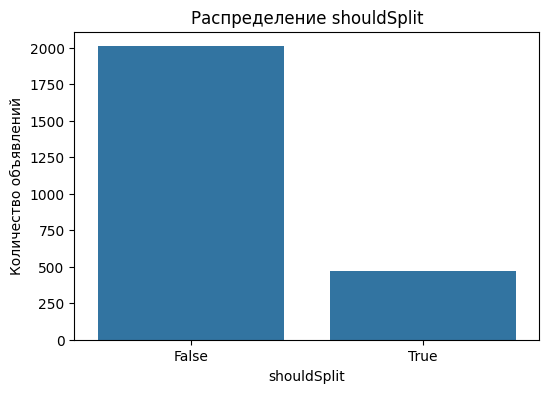

In [44]:
should_split_dist = df["shouldSplit"].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=should_split_dist.index, y=should_split_dist.values)
plt.title("Распределение shouldSplit")
plt.xlabel("shouldSplit")
plt.ylabel("Количество объявлений")
plt.show()

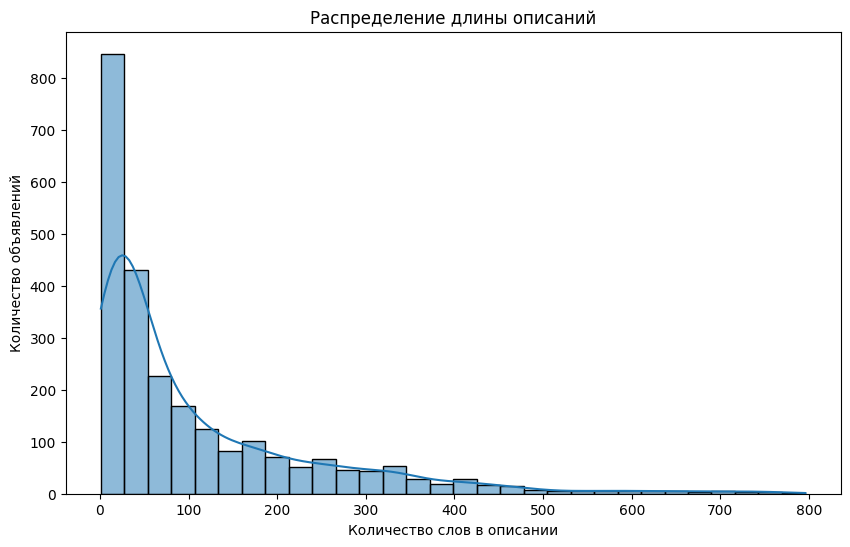

In [46]:
len_desc = df["description"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(len_desc, bins=30, kde=True)
plt.title("Распределение длины описаний")
plt.xlabel("Количество слов в описании")
plt.ylabel("Количество объявлений")
plt.show()

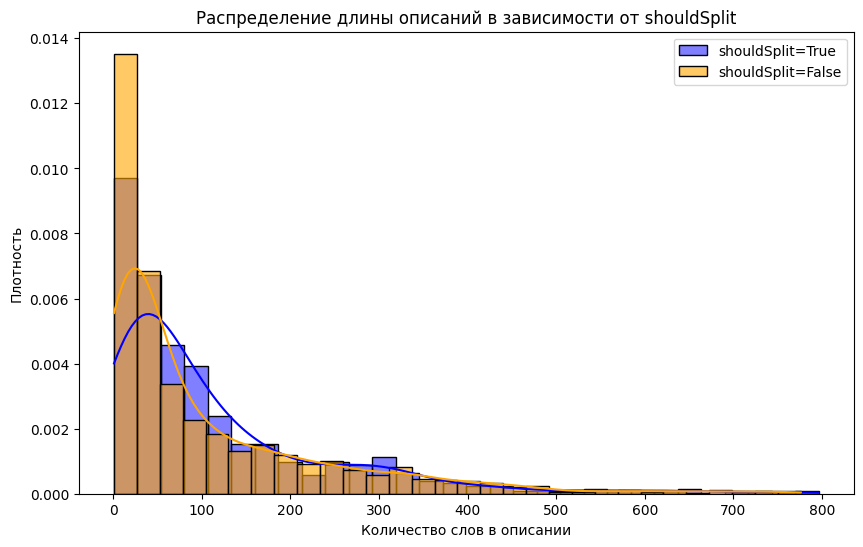

Средняя длина описания для shouldSplit=True: 114.34 слов
Средняя длина описания для shouldSplit=False: 107.18 слов


In [47]:
len_desc_vs_split = df.groupby("shouldSplit")["description"].apply(lambda x: x.apply(lambda desc: len(str(desc).split())))

plt.figure(figsize=(10, 6))
sns.histplot(len_desc_vs_split[True], bins=30, color="blue", label="shouldSplit=True", kde=True, stat="density")
sns.histplot(len_desc_vs_split[False], bins=30, color="orange", label="shouldSplit=False", kde=True, stat="density", alpha=0.6)
plt.title("Распределение длины описаний в зависимости от shouldSplit")
plt.xlabel("Количество слов в описании")
plt.ylabel("Плотность")
plt.legend()
plt.show()

print(f"Средняя длина описания для shouldSplit=True: {len_desc_vs_split[True].mean():.2f} слов")
print(f"Средняя длина описания для shouldSplit=False: {len_desc_vs_split[False].mean():.2f} слов")

In [48]:
!pip install -q nltk
import nltk
from nltk.tokenize import word_tokenize
nltk.download("punkt")
# russian stopwords
nltk.download("stopwords")
stop_words = set(nltk.corpus.stopwords.words("russian"))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


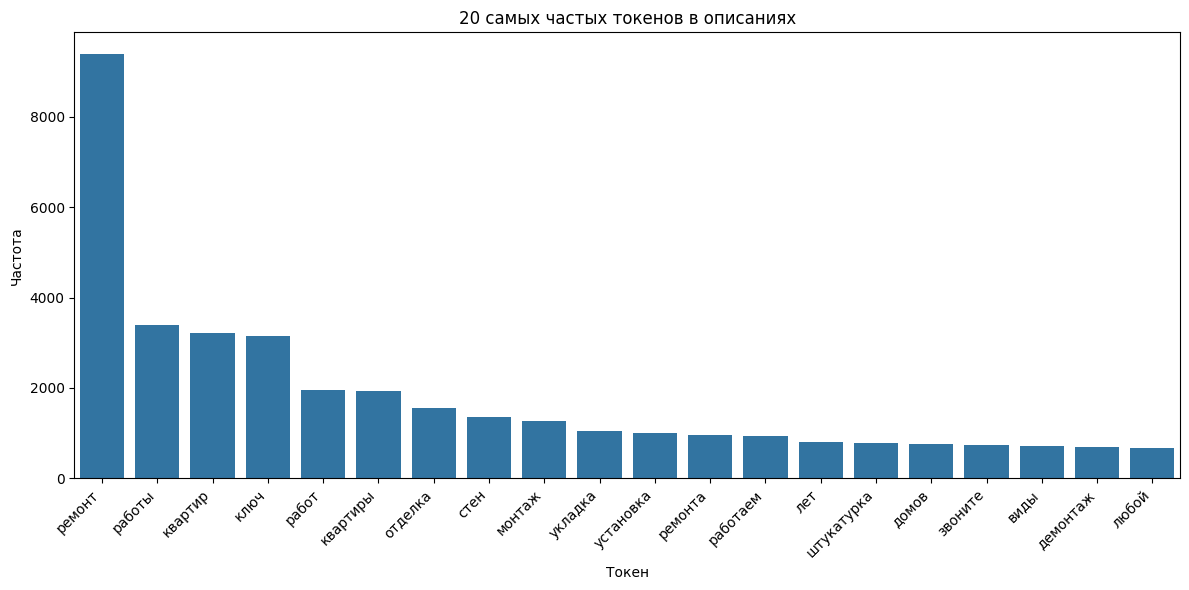

In [50]:
corpus = df["description"].dropna().tolist()
tokenized_corpus = [word_tokenize(desc.lower()) for desc in corpus]
all_tokens = [token for desc in tokenized_corpus for token in desc if token.isalpha() and token.lower() not in stop_words]
token_freq = Counter(all_tokens)
most_common_tokens = token_freq.most_common(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=[token for token, _ in most_common_tokens], y=[freq for _, freq in most_common_tokens])
plt.xticks(rotation=45, ha="right")
plt.title("20 самых частых токенов в описаниях")
plt.xlabel("Токен")
plt.ylabel("Частота")
plt.tight_layout()
plt.show()

## Embeddings

In [51]:
encoder = SentenceTransformerEncoder(EncoderConfig.from_default_yaml())

df["embedding"] = encoder.encode(df["description"].fillna("").tolist())
df.head()

2026-04-07 23:06:39,807 - avito-embeddings - INFO - [AVITO/EMBEDDINGS] Пробую загрузить локальную модель: C:\Users\User\Desktop\dirs\Dev\hack-mfti\avito\checkpoints\rubert-mini-frida
Default prompt name is set to 'Classification'. This prompt will be applied to all `encode()` calls, except if `encode()` is called with `prompt` or `prompt_name` parameters.
2026-04-07 23:06:39,988 - avito-embeddings - INFO - [AVITO/EMBEDDINGS] Запуск encode для 2480 текстов


Batches:   0%|          | 0/78 [00:00<?, ?it/s]

,itemId,sourceMcId,sourceMcTitle,description,targetDetectedMcIds,targetSplitMcIds,shouldSplit,caseType,split,targetDetectedMcTitles,embedding
0,1000001,101,Ремонт квартир и домов под ключ,"Всё виды строительных работ\r\nКачественно, в ...",[],[],False,no_other_microcategories_detected,NaN,[],"[0.07040388137102127, 0.12362894415855408, -0...."
1,1000002,101,Ремонт квартир и домов под ключ,Профессионально и качественно сделаем ремонт к...,"[102, 103, 105, 108, 109, 110]",[],False,other_microcategories_detected_but_not_split,NaN,"[Сантехника, Электрика, Укладка плитки, Штукат...","[0.04899601265788078, 0.110782191157341, 0.026..."
2,1000003,101,Ремонт квартир и домов под ключ,"ремонт квартир, ванной комнате , балкон",[102],[],False,other_microcategories_detected_but_not_split,NaN,[Сантехника],"[0.05225062742829323, 0.15066710114479065, 0.0..."
3,1000004,101,Ремонт квартир и домов под ключ,ЗBОНИТЕ KОHСУЛЬТАЦИЯ БЕCПЛАTНAЯ ПO ТУЛЬСKOЙ ОБ...,"[102, 103, 104, 105, 106, 107, 108, 109, 110]","[102, 103, 104, 105, 106, 107, 108, 109, 110]",True,split,NaN,"[Сантехника, Электрика, Натяжные потолки, Укла...","[0.11510183662176132, 0.12877605855464935, 0.0..."
4,1000005,101,Ремонт квартир и домов под ключ,Ремонт квартир любой сложности. Квартиры под к...,[],[],False,no_other_microcategories_detected,NaN,[],"[-0.002691062167286873, 0.15658238530158997, 0..."


In [52]:
from umap import UMAP
from sklearn.metrics import silhouette_score

import numpy as np

# парсим эмбеддинги
embeddings = np.array(df["embedding"].tolist())
labels_split = df["shouldSplit"].astype(int).values
labels_mc = df["sourceMcTitle"].values
labels_case = df["caseType"].values

# UMAP
reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
emb_2d = reducer.fit_transform(embeddings)
df["umap_x"] = emb_2d[:, 0]
df["umap_y"] = emb_2d[:, 1]

C:\Users\User\anaconda3\envs\hack-mfti\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


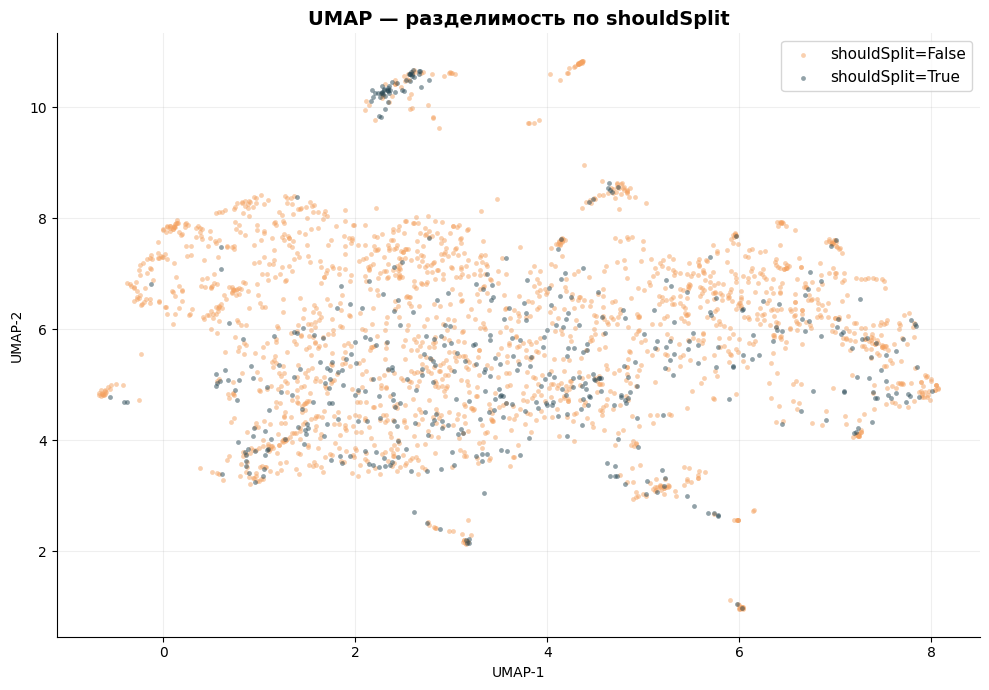

In [53]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = {0: "#f4a261", 1: "#264653"}
for val, label in [(0, "shouldSplit=False"), (1, "shouldSplit=True")]:
    mask = labels_split == val
    ax.scatter(df["umap_x"][mask], df["umap_y"][mask], c=colors[val],
               label=label, alpha=0.5, s=12, linewidths=0)
ax.set_title("UMAP — разделимость по shouldSplit", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.grid(True, alpha=0.2)
sns.despine()
plt.tight_layout()
plt.show()

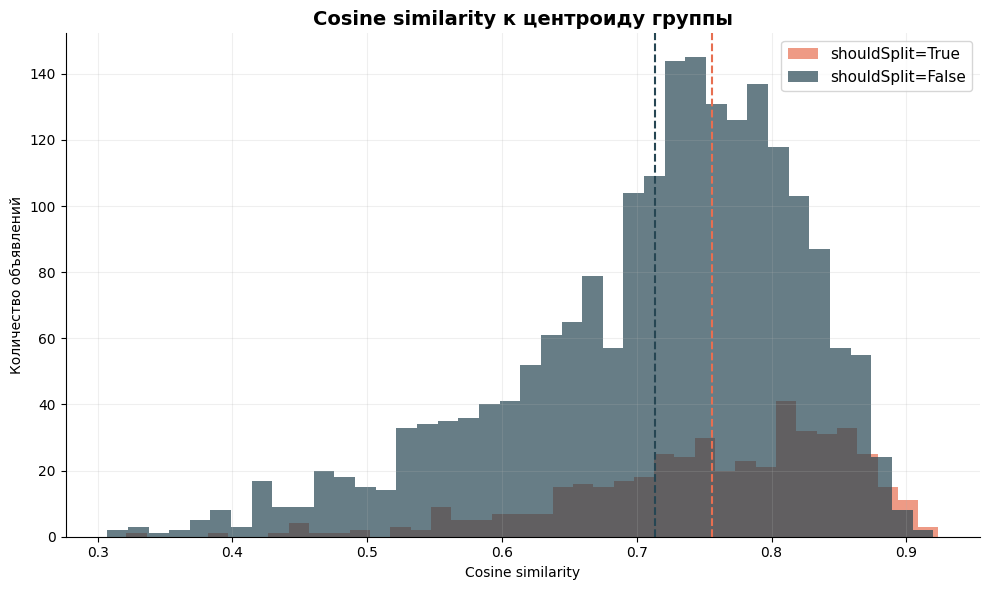

In [57]:
from sklearn.metrics.pairwise import cosine_similarity

mask_split = df["shouldSplit"].values

split_centroid = embeddings[mask_split].mean(axis=0, keepdims=True)
no_split_centroid = embeddings[~mask_split].mean(axis=0, keepdims=True)

split_sims = []
no_split_sims = []

for i, row in df.iterrows():
    emb = embeddings[df.index.get_loc(i)].reshape(1, -1)
    # centroid всех остальных точек той же группы
    if row["shouldSplit"]:
        split_sims.append(cosine_similarity(emb, split_centroid)[0][0])
    else:
        no_split_sims.append(cosine_similarity(emb, no_split_centroid)[0][0])

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(split_sims, bins=40, alpha=0.7, color="#e76f51", label="shouldSplit=True")
ax.hist(no_split_sims, bins=40, alpha=0.7, color="#264653", label="shouldSplit=False")
ax.axvline(np.mean(split_sims), color="#e76f51", linestyle="--", linewidth=1.5)
ax.axvline(np.mean(no_split_sims), color="#264653", linestyle="--", linewidth=1.5)
ax.set_title("Cosine similarity к центроиду группы", fontsize=14, fontweight="bold")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Количество объявлений")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)
sns.despine()
plt.tight_layout()
plt.show()

# Фичи:


## Классификатор shouldSplit:
Текстовые:
- description_word_count
- description_char_count
- split_marker_count        # "отдельно", "также выполняем", "помимо"
- complex_marker_count      # "под ключ", "включая", "в том числе"
- marker_ratio              # split / (complex + 1)
- has_bullets               # есть ли список/перечисление в тексте

Категориальные:
- source_mc_id              # as category
- is_turnkey                # source == "Ремонт квартир и домов под ключ"

Эмбеддинговые:
- embedding (312-dim)       # mini FRIDA, главный сигнал по кластерам

## Детекция микрокатегорий:
- cosine_similarity(chunk_embedding, keyphrase_embeddings)  # bi-encoder
- max_keyphrase_rapidfuzz_mc_<mcId>                         # max rapidfuzz по keyPhrases каждой категории
- nli_entailment_score(description, "селлер предлагает X отдельно")
- split_marker_near_keyphrase                               # "отдельно" в окне ±2 предложения от упоминания категории

Количество rapidfuzz-фич по категориям: 11
Пример колонок: ['max_keyphrase_rapidfuzz_mc_101', 'max_keyphrase_rapidfuzz_mc_102', 'max_keyphrase_rapidfuzz_mc_103', 'max_keyphrase_rapidfuzz_mc_104', 'max_keyphrase_rapidfuzz_mc_105']
Топ категорий по среднему score при shouldSplit=True:
should_split                        False      True 
max_keyphrase_rapidfuzz_mc_106  59.515690  63.992599
max_keyphrase_rapidfuzz_mc_101  63.217587  62.843357
max_keyphrase_rapidfuzz_mc_109  55.745747  62.107708
max_keyphrase_rapidfuzz_mc_105  53.963699  61.351509
max_keyphrase_rapidfuzz_mc_111  55.817039  59.891323
max_keyphrase_rapidfuzz_mc_103  53.560814  59.244644
max_keyphrase_rapidfuzz_mc_107  55.640015  59.193317
max_keyphrase_rapidfuzz_mc_104  48.113117  58.111862
max_keyphrase_rapidfuzz_mc_108  52.849407  57.875328
max_keyphrase_rapidfuzz_mc_102  52.560013  57.425030
max_keyphrase_rapidfuzz_mc_110  47.568253  52.487671


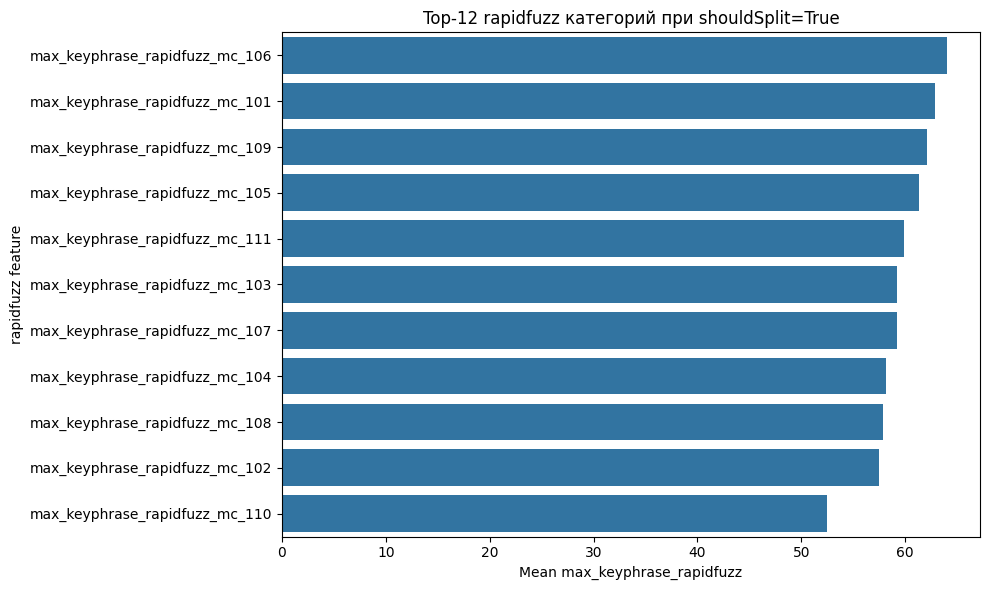

In [58]:
feature_df = extract_should_split_features(df)
rapidfuzz_cols = sorted(
    [col for col in feature_df.columns if col.startswith("max_keyphrase_rapidfuzz_mc_")]
)

print(f"Количество rapidfuzz-фич по категориям: {len(rapidfuzz_cols)}")
print("Пример колонок:", rapidfuzz_cols[:5])

if rapidfuzz_cols:
    rapidfuzz_stats = (
        feature_df[rapidfuzz_cols]
        .assign(should_split=df["shouldSplit"].astype(bool).values)
        .groupby("should_split")
        .mean()
        .T
        .sort_values(by=True, ascending=False)
    )

    print("Топ категорий по среднему score при shouldSplit=True:")
    print(rapidfuzz_stats.head(12))

    plt.figure(figsize=(10, 6))
    top_scores = rapidfuzz_stats.head(12)
    sns.barplot(x=top_scores[True].values, y=top_scores.index)
    plt.title("Top-12 rapidfuzz категорий при shouldSplit=True")
    plt.xlabel("Mean max_keyphrase_rapidfuzz")
    plt.ylabel("rapidfuzz feature")
    plt.tight_layout()
    plt.show()
else:
    print("Rapidfuzz-фичи по категориям не найдены.")